# PHYS-467 Machine Learning for Physicists

Gradient Descent

## Gradient Descent

1.   Load the MNIST dataset and pre-process it;
2. COmpute the gradient analitycally
3.   Write a function that performs gradient descent with $l_2$ regularized binary cross-entropy;
4.   Plot the train and validation loss;
5.   Compute the test MSE and 0/1 loss.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt 

*1. Load MNIST and pre-process it* 

In [ ]:
from keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data() # load the MNIST dataset through keras

11490434/11490434 [==============================] - 1s 0us/step


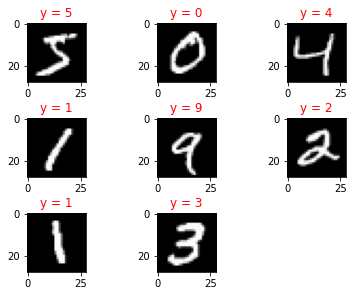

In [ ]:
# display the first 8 digits of the dataset
for i in range(8):  
    plt.subplot(3, 3,  i + 1) # create the plot container
    plt.imshow(X_train[i], cmap=plt.get_cmap('gray')) # plot the image
    plt.tight_layout(pad = 0.3) # add space between subplots
    plt.title("y = " + str(y_train[i]), color = 'red') # print labels as a title
plt.show() # show the plot

In [ ]:
# get info on the dataset
# print shapes of the inputs, of the labels and the maximum and minimum pixel value for both train and test set
#https://colab.research.google.com/drive/1Nox61wfGRNbSnwtmlKHGhaeskQzq6w_U#scrollTo=P67W2sRAE5ur
print("X_train shape = ", np.shape(X_train), "----------------", "y_train shape = ", np.shape(y_train))
print("max pixel value in X_train = ", X_train.max(), "---------------", "min pixel value in X_train = ", X_train.min())
print("")
print("X_test shape = ", np.shape(X_test), "----------------", "y_test shape = ", np.shape(y_test))
print("max pixel value in X_test = ", X_test.max(), "---------------", "min pixel value in X_test = ", X_test.min())

X_train shape =  (60000, 28, 28) ---------------- y_train shape =  (60000,)
max pixel value in X_train =  255 --------------- min pixel value in X_train =  0

X_test shape =  (10000, 28, 28) ---------------- y_test shape =  (10000,)
max pixel value in X_test =  255 --------------- min pixel value in X_test =  0


In [ ]:
# split the dataset in train/test/validation set

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.2, random_state = 42)

In [ ]:
# print again the shapes of the inputs in train, test and validation set

print("X_train shape = ", np.shape(X_train), "--------------", "y_train shape = ", np.shape(y_train))
print("")
print("X_val shape = ", np.shape(X_val), "----------------", "y_val shape = ", np.shape(y_val))
print("")
print("X_test shape = ", np.shape(X_test), "---------------", "y_test shape = ", np.shape(y_test))


X_train shape =  (48000, 28, 28) -------------- y_train shape =  (48000,)

X_val shape =  (12000, 28, 28) ---------------- y_val shape =  (12000,)

X_test shape =  (10000, 28, 28) --------------- y_test shape =  (10000,)


In [ ]:
# pre-process the dataset
def dataset_preprocessing(X_train, y_train, X_val, y_val, X_test, y_test, relabelling_type = "even-odd_digits"):
    """
    This function pre-process the train, test and validation datasets.
    Input:   (X_train, y_train), (X_test, y_test), (X_val, y_val) = train/test/validation set 
            relabelling_type =  partition type of the MNIST dataset. Supported types: even/odd digits, greater/smaller than 5 digits.
    Output:  pre-processed dataset """
    # rescale the inputs in 0-1
    X_train = X_train/255
    X_val = X_val/255
    X_test = X_test/255

    # put images in a vector rather than a matrix
    X_train = np.reshape(X_train, (len(X_train), 28*28))
    X_val = np.reshape(X_val, (len(X_val), 28*28))
    X_test = np.reshape(X_test, (len(X_test), 28*28))

    # rescale the data in order to have pre-activations of order 1
    X_train = X_train/np.sqrt(784)
    X_val = X_val/np.sqrt(784)
    X_test = X_test/np.sqrt(784)

    # relabel MNIST to be suitable for a binary classifier  
    if relabelling_type == "greater-smaller-than-five_digits":
        y_train[y_train <= 5.] = 0
        y_train[y_train > 5.] = 1
        y_val[y_val <= 5.] = 0
        y_val[y_val > 5.] = 1
        y_test[y_test <= 5.] = 0
        y_test[y_test > 5.] = 1
    elif relabelling_type == "even-odd_digits":
        y_train[y_train%2 == 0] = 0
        y_train[y_train%2 == 1] = 1
        y_val[y_val%2 == 0] = 0
        y_val[y_val%2 == 1] = 1
        y_test[y_test%2 == 0] = 0
        y_test[y_test%2 == 1] = 1

    return X_train, y_train, X_val, y_val, X_test, y_test

X_train, y_train, X_val, y_val, X_test, y_test = dataset_preprocessing(X_train, y_train, X_val, y_val, X_test, y_test, relabelling_type="even-odd_digits")

In [ ]:
# look how the dataset has been changed (print shapes of the inputs, of the labels and the maximum and minimum pixel value for both train and test set)

print("X_train shape = ", np.shape(X_train), "----------------", "y_train shape = ", np.shape(y_train))
print("max pixel value in X_train = ", X_train.max(), "---------------", "min pixel value in X_train = ", X_train.min())
print("")
print("X_val shape = ", np.shape(X_val), "----------------", "y_val shape = ", np.shape(y_val))
print("max pixel value in X_val = ", X_val.max(), "---------------", "min pixel value in X_val = ", X_val.min())
print("")
print("X_test shape = ", np.shape(X_test), "----------------", "y_test shape = ", np.shape(y_test))
print("max pixel value in X_test = ", X_test.max(), "---------------", "min pixel value in X_test = ", X_test.min())

X_train shape =  (48000, 784) ---------------- y_train shape =  (48000,)
max pixel value in X_train =  0.03571428571428571 --------------- min pixel value in X_train =  0.0

X_val shape =  (12000, 784) ---------------- y_val shape =  (12000,)
max pixel value in X_val =  0.03571428571428571 --------------- min pixel value in X_val =  0.0

X_test shape =  (10000, 784) ---------------- y_test shape =  (10000,)
max pixel value in X_test =  0.03571428571428571 --------------- min pixel value in X_test =  0.0


### Recap about Logistic Regression
In the logistic model one assumes \begin{equation}
P(y=1|w,x)=\hat y(x)=\frac{1}{1+e^{- w^Tx}}=\sigma(w^Tx),
\end{equation} 
where $\sigma$ is called the sigmid function.
Given some data $y=(y_1,\dots,y_n),\,y\in\{0,1\}$ and $X\in\mathbb R^{n\times d}$
the likelihood of the data is then $P(y|w,X)=\prod_{\mu=1}^d \hat y(X_\mu)^ {y_\mu}+(1-\hat y(X_\mu))^{1-y_\mu}$. 

Taking the logarithm one sees that this is equivalent to the maximization of $\sum_\mu y_\mu \log \hat y(X_\mu)+(1-y_\mu) \log(1- \hat y(X_\mu))$, and hence equivalent to the minimization of the cross entropy loss
$$H(y_\mu,\hat y_\mu)=- y_\mu \log \hat y(X_\mu)-(1-y_\mu) \log(1- \hat y(X_\mu)).$$ The training loss for the whole dataset will then be $L_{train}(y,\hat y)=\frac{1}{n}\sum_{\mu=1}^nH(y_\mu,\hat y_\mu)$.



Note that while this loss emerges naturally when the generative process for $(X,y)$ is the one described by $P(y=1|w,X)$, however in practice people apply it to any data. 

We will also add an $\ell_2$ regularization to the weights, so that the final loss to be optimized is 

$$\mathcal L(w)=L_{train}(w)+\lambda ||w||^2$$

####  Gradient Descent Theory
2. To compute the gradient, complete the missing parts below:

$$\frac{\partial H}{\partial \hat y}=-y/\hat y +(1-y)/(1-\hat y).$$

$$\frac{\partial \hat y(x)}{\partial w_i}=\frac{\partial }{\partial w_i} \frac{1}{1+e^{- w^Tx}}=\frac{ x_i e^{-w^T x}}{(1+e^{-w^Tx})^2}=x_i \hat y(x)(1-\hat y(x)).$$

$$
\frac{\partial H}{\partial w_i}=\frac{\partial H}{\partial \hat y}\frac{\partial \hat y(x)}{\partial w_i}=- x_iy(1-\hat y(x))- x_i\hat y(x) (1-y)=- x_i (y-\hat y(x)).
$$

$$\frac{\partial \mathcal L}{\partial w_i}=\sum_{\mu=1}^n\frac{\partial H}{\partial w_i}(y_\mu,\hat y(X_\mu))+\lambda \frac{\partial ||w||^2}{\partial w_i} =-\sum_{\mu=1}^n X_{\mu i}(y_\mu-\hat y(X_\mu))+2\lambda w_i $$

3. Write gradient descent algorithm

In [ ]:
import time
import pandas as pd
from sklearn.metrics import mean_squared_error

In [ ]:
# write down the gradient descent algorithm

def sigmoid(x):
    """
    This function computes the sigmoid of the pre-activations.
    Input:  x = variable of interest.
    Output: sig = sigmoid.  
    """

    sig = 1/(1+np.exp(-x)) #sigmoid 
    return sig

def binary_cross_entropy_loss(y, y_pred):
    """
    This function computes the binary cross entropy loss given the dataset and the actual estimator. 
    Input: y = actual label;
            y_pred = predicted label.
    Output: bc = binary cross-entropy loss averaged over the dataset.
    """

    bc = -(y*np.log(y_pred)+(1-y)*np.log(1-y_pred)).mean() # computes the binary cross-entropy loss averaged 
    return bc

def gradient(X, y, y_pred):
    """
    This function computes the gradient of the binary-cross entropy loss with respect to the weights and averages the gradient across the whole dataset.
    Input: (X, y) = dataset;
            y_pred = predicted labels.
    Output: mean of the gradient across the dataset
    """
    grad=-np.sum(np.einsum('ij,i->ij',X,y-y_pred),axis=0) # gradient of the binary cross-entropy loss
    return grad 
    
def run_gd(X, y, X_val, y_val, lamb, eta, epochs, tol, frequency, verbose, n_iter_no_change):
    """
    This function runs the gradient descent algorithm and saves the results on file.
    Input: (X, y), (X_val, y_val) = train and validation set;
            lamb = regularization strength;
            eta = learning rate;
            epochs = maximum number of iterations;
            tol = tolerance;
            frequency = frequency at which the results are printed on the screen;
            verbose = flag to decide whether to print or not information about the algorithm convergence;
            n_iter_no_change = number of iterations we want to wait when the train loss starts not changing more than tol accross the epochs (then the dynamics will be stopped). 
    Output: W = estimated weights 
    """  
    res = {"epoch": [], "train_loss": [], "val_loss": [], "gradient_norm": []} # initialize an empty disctionary where to save results  
    W = np.random.normal(0., 1., size = (len(X[0]))) # initialize the weights
    counter_train = 0
    train_loss_prec = 100
    y_pred = sigmoid(np.einsum('ji,i->j',X,W)) # compute the predicted labels at epoch = 0

    for epoch in range(epochs): # loop over epochs    
        # compute the gradient and update the weights    
        grad = gradient(X,y,y_pred) #mean gradient across dataset
        W =W - eta * grad - eta * 2 * lamb * W # update the weights (put in the contribution of the regularization)
        norm_grad = np.linalg.norm(grad)  

        # compute the metrics (train and validation losses, norm of the gradient) for the new estimator
        y_pred = sigmoid(X @ W) # compute the predicted labels
        train_loss = binary_cross_entropy_loss(y, y_pred)
        y_pred_val = sigmoid(X_val @ W) # compute the predicted labels
        val_loss = binary_cross_entropy_loss(y_val, y_pred_val)

        # save the results by populating the dictionary res
        res["epoch"].append(epoch) # populate the dictionary
        res["train_loss"].append(train_loss)
        res["val_loss"].append(val_loss)
        res["gradient_norm"].append(norm_grad)

        # check whether the algorithm is converging    
        if epoch % frequency == 0 and verbose == 1: # display results
            print("epoch: ", epoch, "train loss = ", train_loss, "val loss = ", val_loss, "gradient_norm = ", norm_grad)
        if np.abs(train_loss_prec - train_loss)/eta <= tol: # check whether the loss is not moving
            counter_train += 1 # update the counter
            if counter_train >= n_iter_no_change: # check whether the loss has not changed in a certain time interval 
                print("GD converged to tolerance %.8f"%tol)
                break # if yes exit the loop - A) indented
        else:
            counter_train = 0

        train_loss_prec = train_loss # assign to the previous training loss its actual value

    res = pd.DataFrame.from_dict(res) # translate the dictionary into a pandas dataframe
    res.to_csv("./training_gd.csv", mode = 'w', index = False) # write the csv file
    return W  

In [ ]:
# Run GD
n = 1000
X_train_slice = X_train[:n]
y_train_slice = y_train[:n]
eta = 0.1
epochs = 1500
lamb = 1e-5
tol = 1e-5
frequency = 1
verbose = 1
n_iter_no_change = 5

start = time.time() # starting time
W_gd = run_gd(X_train_slice, y_train_slice, X_val, y_val, lamb, eta, epochs, tol, frequency, verbose, n_iter_no_change)
print("total computational time in seconds = ", time.time() - start) # print how much the algorithm took to run for a number of epochs = epochs

epoch:  0 train loss =  0.6579884219092215 val loss =  0.6654346170213314 gradient_norm =  36.0946870649176
epoch:  1 train loss =  0.61730212259522 val loss =  0.6256889564037701 gradient_norm =  21.10524267545526
epoch:  2 train loss =  0.5854346673415542 val loss =  0.595297357294156 gradient_norm =  18.32175337080066
epoch:  3 train loss =  0.5594110023422506 val loss =  0.570351337414156 gradient_norm =  16.516407293464326
epoch:  4 train loss =  0.5378091742694562 val loss =  0.5496606523540465 gradient_norm =  15.020133983674162
epoch:  5 train loss =  0.5196089186794227 val loss =  0.5322436026171812 gradient_norm =  13.76345209128764
epoch:  6 train loss =  0.5040627578425146 val loss =  0.5173933192118392 gradient_norm =  12.700580947673574
epoch:  7 train loss =  0.49061784166385225 val loss =  0.5045826849170759 gradient_norm =  11.794580321684174
epoch:  8 train loss =  0.47886051256697454 val loss =  0.49341558401838365 gradient_norm =  11.015766275768499
epoch:  9 train 

*4. Plot train and validation loss* 

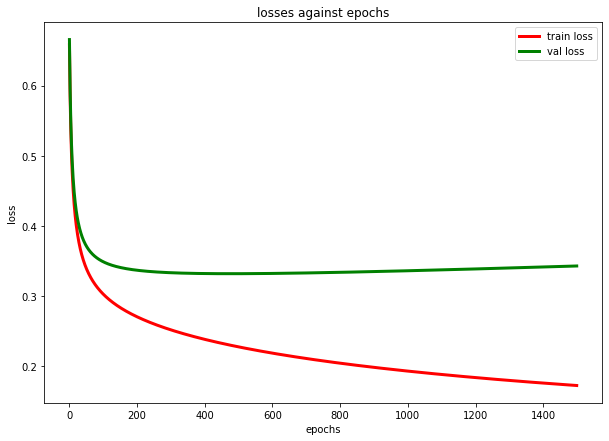

In [ ]:
# plot the results (i.e. plot train and validation loss as a function of the epoch)

fig, ax = plt.subplots(figsize=(10,7)) # initialize an empty figure and axes object
res = pd.read_csv("./training_gd.csv") # read the content of the *.csv file

res.plot(x='epoch',
         y='train_loss',
         color = 'red',
         lw = 3, # linewidth
         ax=ax, # to plot in the same figure
         label='train loss') # plot the results with matplotlib through pandas

res.plot(x='epoch',
         y='val_loss',
         color = 'green',
         lw = 3,
         ax=ax,
         label='val loss')

ax.set_title("losses against epochs") # set the plot title
ax.set_ylabel("loss") # set the name of the y axis
ax.set_xlabel("epochs") # set the name of the x axis
#ax.set_xlim(0.3,10**(-10)) # set the range of the x axis
ax.legend(loc = 'upper right') # specify the position of the legend

5. Compute the test mean square loss and 0/1 loss.

For the 0/1 loss one needs to have a hard criterion for classification (i.e. either the classifier outputs 0 or 1, and nothing in between). Convince yourself that it makes sense to take $\hat y_{hard}(x)=\Theta(\hat y(x)-1/2)$.

In [ ]:
# compute the test error for the gd estimators
y_test_pred = sigmoid(X_test@W_gd) # compute the prediction
test_mse_gd = mean_squared_error(y_test, y_test_pred) # compute the test error.
test_01_gd = np.mean(y_test != np.heaviside(y_test_pred-0.5,1)) # compute the test error.

print("The MSE associated to the estimator computed by GD is: ", test_mse_gd) # print it
print("The 0/1 loss associated to the estimator computed by GD is:", test_01_gd) # 

The MSE associated to the estimator computed by GD is:  0.0972822440289449
The 0/1 loss associated to the estimator computed by GD is: 0.1312


## Stochastic Gradient Descent

6.   Write a function that performs stochastic gradient descent algoritm (batch size = 10) with $l_2$ regularized binary cross-entropy;
7.   Plot the training loss versus epochs for both gradient descent and stochastic gradient descent;
8.   Compute the test MSE and 0/1 loss

6. Write a function that performs Stochastic Gradient Descent (SGD) (namely
mini-batch GD with batch size = 10) with binary cross-entropy loss and
$\ell_2$ regularization

Split the training set into batches of the desired size, then in each epoch (i.e. in each pass over the dataset) select batches in a random order and use them to update the weights. The function `np.random.permutation` might help

In [ ]:
def run_sgd(X, y, X_val, y_val, lamb, eta, epochs, tol, frequency, verbose, n_iter_no_change, batch_size):
    """
    This function run the stochastic gradient descent algorithm and save results on file.
    Input: (X, y), (X_val, y_val) = train and validation set;
            lamb = regularization strength;
            eta = learning rate;
            epochs = maximum number of passes over the whole dataset;
            tol = convergence tolerance;
            frequency = frequency at which the results are printed on the screen;
            verbose = flag to decide whether to print or not information about the algorithm convergence;
            n_iter_no_change = number of iterations we want to wait when the train loss starts not changing more than tol accross the epochs
            batch_size = size of the SGD batches
    Output: W = estimated weights 
    """  


    res = {"epoch": [], "train_loss": [], "val_loss": [], "gradient_norm": []} # initialize an empty disctionary where to save results  
    W = np.random.normal(0., 1., size = (len(X[0]))) # initialize the weights
    counter_train = 0
    train_loss_prec = 100
    num_batches=len(y)//batch_size
    for epoch in range(epochs): # loop over epochs    
        rand_perm=np.random.permutation(num_batches)
        for b in rand_perm:
            X_b=X[b*batch_size:(b+1)*batch_size]
            y_b=y[b*batch_size:(b+1)*batch_size]
            y_b_pred=sigmoid(X_b @ W)
            # compute the gradient and update the weights    
            grad = gradient(X_b,y_b,y_b_pred) #mean gradient across dataset
            W =W - eta * grad - lamb * W # update the weights (put in the contribution of the regularization)

        norm_grad = np.linalg.norm(grad)# norm of gradient over the last batch
        # compute the metrics for the new estimator
        y_pred = sigmoid(X @ W) # compute the predicted labels
        train_loss = binary_cross_entropy_loss(y, y_pred)
        y_pred_val = sigmoid(X_val @ W) # compute the predicted labels
        val_loss = binary_cross_entropy_loss(y_val, y_pred_val)

        # save the results
        res["epoch"].append(epoch) # populate the dictionary
        res["train_loss"].append(train_loss)
        res["val_loss"].append(val_loss)
        res["gradient_norm"].append(norm_grad)

        # check whether the algorithm is converging    
        if epoch % frequency == 0 and verbose == 1: # display results
            print("epoch: ", epoch, "train loss = ", train_loss, "val loss = ", val_loss, "gradient_norm = ", norm_grad)
        if np.abs(train_loss_prec - train_loss)/eta <= tol: # check whether the loss is not moving
            counter_train += 1 # update the counter
            if counter_train >= n_iter_no_change: # check whether the loss has not changed in a certain time interval 
                print("GD converged to tolerance %.8f"%tol)
                break # if yes exit the loop
        else:
            counter_train = 0

        train_loss_prec = train_loss # assign to the previous training loss its actual value

    res = pd.DataFrame.from_dict(res) # translate the dictionary into a pandas dataframe
    res.to_csv("./training_sgd.csv", mode = 'w', index = False) # write the csv file
    return W  

In [ ]:
# Run SGD 
start = time.time() # starting time
epochs=1500
W_sgd = run_sgd(X_train_slice, y_train_slice, X_val, y_val, lamb, eta, epochs, tol, frequency, verbose, n_iter_no_change, batch_size=10)
print("total computational time in seconds = ", time.time() - start) # print how much the algorithm took to run for a number of epochs = epochs

epoch:  0 train loss =  0.6679704665921732 val loss =  0.675630504336445 gradient_norm =  0.38719497827043114
epoch:  1 train loss =  0.6274630365508185 val loss =  0.6375433572573159 gradient_norm =  0.4834310137935227
epoch:  2 train loss =  0.595673481399397 val loss =  0.6070527626710703 gradient_norm =  0.4463203963124181
epoch:  3 train loss =  0.5692474996822298 val loss =  0.5817517471710798 gradient_norm =  0.41599458331253775
epoch:  4 train loss =  0.547100743410608 val loss =  0.5604964825980645 gradient_norm =  0.6488755534522442
epoch:  5 train loss =  0.5283135868707834 val loss =  0.5424692380533148 gradient_norm =  0.6668531949186993
epoch:  6 train loss =  0.5122123654878107 val loss =  0.5270076536921406 gradient_norm =  0.3722166934993196
epoch:  7 train loss =  0.4982035056567995 val loss =  0.5135637331961316 gradient_norm =  0.3391567249327231
epoch:  8 train loss =  0.4859226523732802 val loss =  0.5017994649117437 gradient_norm =  0.46901391082287497
epoch:  9 

7. plot train losses for both GD and SGD

---



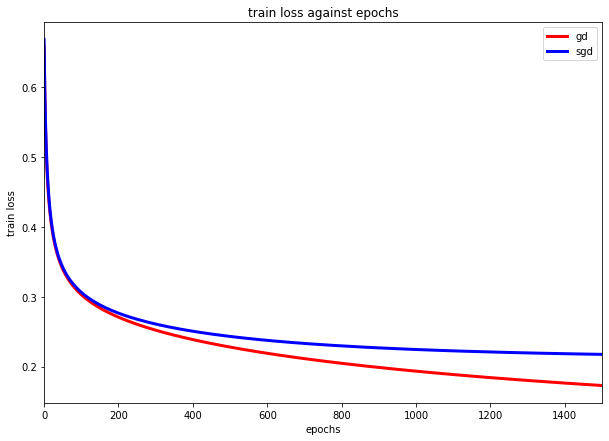

In [ ]:
# plot the train loss for both gd and sgd

fig, ax = plt.subplots(figsize=(10,7)) # initialize an empty figure and axes object
res_gd = pd.read_csv("./training_gd.csv") # read the content of the *.csv file
res_sgd = pd.read_csv("./training_sgd.csv") # read the content of the *.csv file

res_gd.plot(x='epoch',
         y='train_loss',
         color = 'red',
         lw = 3, # linewidth
         ax=ax, # to plot in the same figure
         label='gd') # plot the results with matplotlib through pandas


res_sgd.plot(x='epoch',
         y='train_loss',
         color = 'blue',
         lw = 3,
         ax=ax,
         label='sgd')

ax.set_title("train loss against epochs") # set the plot title
ax.set_ylabel("train loss") # set the name of the y axis
ax.set_xlabel("epochs") # set the name of the x axis
ax.set_xlim(0.0,1500) # set the range of the x axis
ax.legend(loc = 'upper right') # specify the position of the legend

8.  Compute the mean square error and 0/1 loss of SGD and compare with those of GD

In [ ]:
# compute the test error for sgd

y_test_pred = sigmoid(X_test@W_gd) # compute the prediction
test_error_gd = mean_squared_error(y_test, y_test_pred) # compute the test error for GD
test_01_gd = np.mean(y_test != np.heaviside(y_test_pred-0.5,1)) # compute the test error.

print("The test MSE associated to the estimator computed by gd is: ", test_error_gd) # print it
print("The test 0/1 loss associated to the estimator computed by gd is: ", test_01_gd) # print it

y_test_pred = sigmoid(X_test@W_sgd) # compute the prediction
test_error_sgd = mean_squared_error(y_test, y_test_pred) # compute the test error for SGD
test_01_sgd = np.mean(y_test != np.heaviside(y_test_pred-0.5,1)) # compute the test error.

print("The test error associated to the estimator computed by sgd is: ", test_error_sgd) # print it
print("The test 0/1 loss associated to the estimator computed by sgd is: ", test_01_sgd) # print it


The test MSE associated to the estimator computed by gd is:  0.0972822440289449
The test 0/1 loss associated to the estimator computed by gd is:  0.1312
The test error associated to the estimator computed by sgd is:  0.09590471982765703
The test 0/1 loss associated to the estimator computed by sgd is:  0.1297


9. Use scikit learn’s built in function for logistic regression to obtain the
estimator. Compute and print test MSE and 0/1 test loss.


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
logistic_regr = LogisticRegression(random_state=0,C=1/lamb).fit(X_train, y_train)
y_test_pred=logistic_regr.predict_proba(X_test)[:,1]
test_mse_sklearn=mean_squared_error(y_test,y_test_pred)
test_01_sklearn=np.mean(y_test != logistic_regr.predict(X_test))
print("The test error associated to the estimator computed by sklearn is: ", test_mse_sklearn) # print it
print("The test 0/1 loss associated to the estimator computed by skelarnis: ", test_01_sklearn) # print it


The test error associated to the estimator computed by sklearn is:  0.07505026929047745
The test 0/1 loss associated to the estimator computed by skelarnis:  0.1012


/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,
